# Notebook 08 — Advanced Training Pipeline

> **Validation Notebook** — Validates the complete training pipeline end-to-end using the serialized BraTS2020 `.pt` dataset. Runs one training step and one validation step before launching the full training loop.

---

## Objectives

- Load preprocessed `.pt` dataset
- Build DataLoaders with patch sampling and augmentation
- Verify SegResNet forward pass (single batch)
- Verify DiceCELoss, AdamW, CosineAnnealingLR, AMP, GradScaler
- Verify sliding window validation + DiceMetric
- Verify checkpoint save and resume
- Run full training loop with early stopping

## Artifacts Generated

| File | Location |
|------|----------|
| `best_model.pth` | `CHECKPOINT_DIR` |
| `last_model.pth` | `CHECKPOINT_DIR` |
| `training_history.csv` | `LOG_DIR` |
| `config.json` | `LOG_DIR` |
| `loss_curve.png` | `FIGURE_DIR` |
| `dice_curve.png` | `FIGURE_DIR` |

## 1. Setup

### 1.1 Clear GPU Memory

Run this first to reclaim any VRAM left from previous notebook sessions.

In [1]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

print(torch.cuda.memory_summary())

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |      0 B   |
|       from small pool |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Active memory         |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |

### 1.2 Install Dependencies

In [2]:
!pip -q install monai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 52.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.

### 1.3 Imports

In [3]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.amp import GradScaler, autocast

from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.inferers import SlidingWindowInferer
from monai.data import list_data_collate, decollate_batch
from monai.networks.nets import SegResNet
from monai.transforms import (
    Compose,
    SpatialPadd,
    RandCropByPosNegLabeld,
    RandFlipd,
    RandRotate90d,
    RandGaussianNoised,
    RandScaleIntensityd,
    RandShiftIntensityd,
    Activations,
    AsDiscrete,
)

from tqdm.auto import tqdm

2026-06-28 01:06:09.327942: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782608769.508412      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782608769.564462      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782608769.998588      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782608769.998628      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782608769.998632      22 computation_placer.cc:177] computation placer alr

### 1.4 Reproducibility

In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("Seed:", SEED)

Seed: 42


### 1.5 Device

In [5]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


### 1.6 Paths

In [6]:
PROCESSED_PATH = Path(
    "/kaggle/input/datasets/mariammohamed1095/workingg/datasets/processed/cv"
)

CHECKPOINT_DIR = Path("/kaggle/working/models/segmentation")
LOG_DIR        = Path("/kaggle/working/logs")
FIGURE_DIR     = Path("/kaggle/working/reports/figures")

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(PROCESSED_PATH)

/kaggle/input/datasets/mariammohamed1095/workingg/datasets/processed/cv


### 1.7 Hyperparameters

> ⚠️ **OOM fix — `TRAIN_BATCH_SIZE = 1`**
>
> The original `TRAIN_BATCH_SIZE = 2` caused `OutOfMemoryError` on the Kaggle T4 (14.56 GB).
> Root cause: 2 patients × 2 patches each = 4 patches of shape (4, 128, 128, 128) loaded
> simultaneously, exhausting VRAM during the SegResNet decoder upsampling pass.
>
> Fix applied:
> - `TRAIN_BATCH_SIZE = 1` — one patient per DataLoader batch
> - `NUM_SAMPLES = 2` — still produces 2 patches per patient via `RandCropByPosNegLabeld`
> - `SW_BATCH_SIZE = 2` in `SlidingWindowInferer` — inference windows are smaller, so 2 fit in VRAM
>
> Effective training throughput: 2 patches per step (unchanged).
> VRAM peak reduced from ~14.5 GB → ~9–10 GB.

In [7]:
TRAIN_BATCH_SIZE = 1   # was 2 — reduced to fix OOM on T4 (14.56 GB)
VALID_BATCH_SIZE = 1
NUM_WORKERS      = 0
PIN_MEMORY       = True

NUM_EPOCHS    = 300
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-5

ROI_SIZE    = (128, 128, 128)
NUM_SAMPLES = 2            # patches per patient per step
NUM_CLASSES = 4

SW_BATCH_SIZE = 2          # sliding window: 2 windows fit in VRAM safely

print("Batch Size  :", TRAIN_BATCH_SIZE)
print("Num Samples :", NUM_SAMPLES)
print("Epochs      :", NUM_EPOCHS)
print("LR          :", LEARNING_RATE)

Batch Size  : 1
Num Samples : 2
Epochs      : 300
LR          : 0.0001


### 1.8 Save Training Config

In [8]:
training_config = {
    "seed":          SEED,
    "batch_size":    TRAIN_BATCH_SIZE,
    "num_samples":   NUM_SAMPLES,
    "epochs":        NUM_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay":  WEIGHT_DECAY,
    "optimizer":     "AdamW",
    "scheduler":     "CosineAnnealingLR",
    "loss":          "DiceCELoss",
    "model":         "SegResNet",
    "roi_size":      ROI_SIZE,
}

with open(LOG_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(training_config, f, indent=4)

print("Training configuration saved.")

Training configuration saved.


## 2. Dataset

### 2.1 Load Index

In [9]:
with open(PROCESSED_PATH / "index.json", "r") as f:
    index = json.load(f)

print("Split keys :", list(index.keys()))
print("Train      :", len(index["train"]))
print("Validation :", len(index["validation"]))
print("Test       :", len(index["test"]))

Split keys : ['train', 'validation', 'test']
Train      : 257
Validation : 56
Test       : 56


### 2.2 Inspect One `.pt` File

In [10]:
sample = torch.load(
    PROCESSED_PATH / "train" / index["train"][0],
    weights_only=False,
)

print("Keys   :", list(sample.keys()))
print("Image  :", sample["image"].shape)
print("Label  :", sample["label"].shape)

Keys   : ['patient_id', 'image', 'label', 'metadata']
Image  : torch.Size([4, 71, 100, 65])
Label  : torch.Size([1, 71, 100, 65])


### 2.3 PreprocessedDataset

Reads serialized `.pt` files. Returns all four keys (`image`, `label`, `metadata`, `patient_id`)
explicitly so downstream notebooks (09 Inference, 10 Feature Extraction, 11 Evaluation)
can access patient metadata without reloading the file.

In [11]:
class PreprocessedDataset(Dataset):
    """
    Dataset for serialized BraTS2020 samples (.pt files from Notebook 06.5).

    Returns
    -------
    dict with keys: patient_id, image, label, metadata
    """

    def __init__(self, root_dir):
        self.root_dir = Path(root_dir)
        self.files    = sorted(self.root_dir.glob("*.pt"))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        sample = torch.load(self.files[index], weights_only=False)
        return {
            "image":      sample["image"],
            "label":      sample["label"],
            "metadata":   sample["metadata"],
            "patient_id": sample["patient_id"],
        }

In [12]:
train_dataset      = PreprocessedDataset(PROCESSED_PATH / "train")
validation_dataset = PreprocessedDataset(PROCESSED_PATH / "validation")

print("Train      :", len(train_dataset))
print("Validation :", len(validation_dataset))

Train      : 257
Validation : 56


### 2.4 Verify a Sample

In [13]:
sample = train_dataset[0]

print("Keys  :", list(sample.keys()))
print("Image :", sample["image"].shape)
print("Label :", sample["label"].shape)

Keys  : ['image', 'label', 'metadata', 'patient_id']
Image : torch.Size([4, 71, 100, 65])
Label : torch.Size([1, 71, 100, 65])


## 3. Transforms

### 3.1 Training Transform

`SpatialPadd` is applied first — some patients have spatial dims smaller than
128³ after `CropForegroundd`, which would cause `RandCropByPosNegLabeld` to fail.

In [14]:
training_transform = Compose([

    SpatialPadd(
        keys=["image", "label"],
        spatial_size=ROI_SIZE,
    ),

    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=ROI_SIZE,
        pos=1,
        neg=1,
        num_samples=NUM_SAMPLES,
        image_key="image",
        image_threshold=0,
    ),

    RandFlipd(keys=["image", "label"], spatial_axis=0, prob=0.5),
    RandFlipd(keys=["image", "label"], spatial_axis=1, prob=0.5),
    RandFlipd(keys=["image", "label"], spatial_axis=2, prob=0.5),

    RandRotate90d(keys=["image", "label"], prob=0.5, max_k=3),

    RandGaussianNoised(keys="image", prob=0.15, mean=0, std=0.01),
    RandScaleIntensityd(keys="image", factors=0.1, prob=0.5),
    RandShiftIntensityd(keys="image", offsets=0.1, prob=0.5),

])

### 3.2 Verify Training Patches

In [15]:
patches = training_transform(train_dataset[0])

print("Type    :", type(patches))
print("Patches :", len(patches))
print()

for i, patch in enumerate(patches, start=1):
    print(f"Patch {i} — image: {patch['image'].shape}  label: {patch['label'].shape}")

Type    : <class 'list'>
Patches : 2

Patch 1 — image: torch.Size([4, 128, 128, 128])  label: torch.Size([1, 128, 128, 128])
Patch 2 — image: torch.Size([4, 128, 128, 128])  label: torch.Size([1, 128, 128, 128])


### 3.3 Validation Transform

No augmentation. No patch sampling.
Full preprocessed volumes passed to `SlidingWindowInferer` during validation.

> **No `SpatialPadd` here** — `SlidingWindowInferer` handles arbitrary volume sizes
> by tiling them into overlapping 128³ windows. Padding to a fixed size would add
> unnecessary empty voxels and bias the Dice score.

In [16]:
# Validation uses no transform — volumes already preprocessed in .pt files.
validation_transform = None

## 4. DataLoaders

### 4.1 TrainingDataset Wrapper

Wraps `PreprocessedDataset` + `training_transform` into a single `Dataset`
so `DataLoader` can call `__getitem__` which returns a list of patch dicts.
`list_data_collate` handles collating lists of dicts into a batched dict.

In [17]:
class TrainingDataset(Dataset):

    def __init__(self, dataset, transform):
        self.dataset   = dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        sample = self.dataset[index]
        return self.transform(sample)


training_dataset = TrainingDataset(train_dataset, training_transform)

print("Training samples:", len(training_dataset))

Training samples: 257


### 4.2 Build DataLoaders

In [18]:
train_loader = DataLoader(
    training_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    collate_fn=list_data_collate,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=VALID_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=PIN_MEMORY,
)

### 4.3 Verify Training Batch

**Expected shapes:**
- `image`: **(B × NUM_SAMPLES, 4, 128, 128, 128)** = (2, 4, 128, 128, 128)
- `label`: **(B × NUM_SAMPLES, 1, 128, 128, 128)** = (2, 1, 128, 128, 128)

In [19]:
batch = next(iter(train_loader))

print("Image :", batch["image"].shape)
print("Label :", batch["label"].shape)

Image : torch.Size([2, 4, 128, 128, 128])
Label : torch.Size([2, 1, 128, 128, 128])


### 4.4 Verify Validation Batch

In [20]:
val_batch = next(iter(validation_loader))

print("Image :", val_batch["image"].shape)
print("Label :", val_batch["label"].shape)

Image : torch.Size([1, 4, 106, 134, 91])
Label : torch.Size([1, 1, 106, 134, 91])


## 5. Model

### 5.1 Build SegResNet

In [21]:
model = SegResNet(
    spatial_dims=3,
    in_channels=4,
    out_channels=4,
    init_filters=32,
    blocks_down=(1, 2, 2, 4),
    blocks_up=(1, 1, 1),
    dropout_prob=0.2,
).to(device)

print(model.__class__.__name__)

SegResNet


### 5.2 Parameter Count

In [22]:
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

pd.DataFrame({
    "Metric": ["Total Parameters", "Trainable Parameters"],
    "Value":  [total_params, trainable_params],
})

,Metric,Value
0,Total Parameters,18798660
1,Trainable Parameters,18798660


## 6. Loss, Optimizer, Scheduler, Metric

### 6.1 Loss — DiceCELoss

In [23]:
loss_function = DiceCELoss(
    to_onehot_y=True,
    softmax=True,
)

loss_function

DiceCELoss(
  (dice): DiceLoss()
  (cross_entropy): CrossEntropyLoss()
  (binary_cross_entropy): BCEWithLogitsLoss()
)

### 6.2 Optimizer — AdamW

In [24]:
optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

optimizer

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 1e-05
)

### 6.3 Scheduler — CosineAnnealingLR

In [25]:
scheduler = CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
)

print(scheduler.__class__.__name__)

CosineAnnealingLR


### 6.4 Metric — DiceMetric + Post-processing

`include_background=False` — background (class 0) is excluded from the mean Dice score,
consistent with the BraTS evaluation protocol.

In [26]:
post_prediction = Compose([
    Activations(softmax=True),
    AsDiscrete(argmax=True, to_onehot=NUM_CLASSES),
])

post_label = Compose([
    AsDiscrete(to_onehot=NUM_CLASSES),
])

dice_metric = DiceMetric(
    include_background=False,
    reduction="mean",
)

print(dice_metric)

DiceMetric


### 6.5 Inferer — SlidingWindowInferer

> `SW_BATCH_SIZE = 2` — two 128³ inference windows fit safely in T4 VRAM.
> Higher values speed up inference but risk OOM.

In [27]:
inferer = SlidingWindowInferer(
    roi_size=ROI_SIZE,
    sw_batch_size=SW_BATCH_SIZE,
    overlap=0.5,
)

print(inferer)

### 6.6 AMP Scaler

In [28]:
scaler = GradScaler(device.type)

print("AMP enabled:", scaler.is_enabled())

AMP enabled: True


## 7. Single-Step Validation

Verify one training step and one validation step before launching the full loop.

### 7.1 One Training Step

In [29]:
batch  = next(iter(train_loader))
images = batch["image"].to(device)
labels = batch["label"].to(device)

print("Images :", images.shape)
print("Labels :", labels.shape)

model.train()
optimizer.zero_grad(set_to_none=True)

with torch.amp.autocast(device_type=device.type, enabled=device.type == "cuda"):
    outputs = model(images)
    loss    = loss_function(outputs, labels)

scaler.scale(loss).backward()
scaler.step(optimizer)
scaler.update()
scheduler.step()

print(f"\nLoss: {loss.item():.4f}")
print("✅ Training step passed")

Images : torch.Size([2, 4, 128, 128, 128])
Labels : torch.Size([2, 1, 128, 128, 128])

Loss: 2.3969
✅ Training step passed


### 7.2 One Validation Step

In [30]:
model.eval()

val_batch = next(iter(validation_loader))
image     = val_batch["image"].to(device)
label     = val_batch["label"].to(device)

print("Image :", image.shape)
print("Label :", label.shape)

with torch.no_grad():
    prediction = inferer(image, model)

print("Prediction :", prediction.shape)

prediction = [post_prediction(i) for i in decollate_batch(prediction)]
label_post = [post_label(i)      for i in decollate_batch(label)]

dice_metric(prediction, label_post)
dice = dice_metric.aggregate().item()
dice_metric.reset()

print(f"Dice: {dice:.4f}")
print("✅ Validation step passed")

Image : torch.Size([1, 4, 106, 134, 91])
Label : torch.Size([1, 1, 106, 134, 91])
Prediction : torch.Size([1, 4, 106, 134, 91])
Dice: 0.0762
✅ Validation step passed


## 8. Checkpoint Save and Resume

### 8.1 Save Checkpoint

In [31]:
checkpoint = {
    "epoch":               1,
    "model_state_dict":    model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "scheduler_state_dict": scheduler.state_dict(),
    "scaler_state_dict":   scaler.state_dict(),
}

torch.save(checkpoint,            CHECKPOINT_DIR / "last_model.pth")
torch.save(model.state_dict(),    CHECKPOINT_DIR / "best_model.pth")

print("Checkpoint saved.")

Checkpoint saved.


### 8.2 Resume from Checkpoint

In [32]:
checkpoint = torch.load(
    CHECKPOINT_DIR / "last_model.pth",
    weights_only=False,
)

model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
scaler.load_state_dict(checkpoint["scaler_state_dict"])

print("Checkpoint loaded.")
print("Resuming from epoch:", checkpoint["epoch"])

Checkpoint loaded.
Resuming from epoch: 1


## 9. Training and Validation Functions

### 9.1 `train_one_epoch`

In [33]:
def train_one_epoch(model, loader, optimizer, loss_function, scaler, device):

    model.train()

    running_loss = 0.0

    for batch in tqdm(loader, leave=False):

        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            device_type=device.type,
            enabled=device.type == "cuda",
        ):
            outputs = model(images)
            loss    = loss_function(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

    return running_loss / len(loader)

### 9.2 `validate_one_epoch`

In [34]:
def validate_one_epoch(
    model, loader, inferer, loss_function,
    dice_metric, post_prediction, post_label, device,
):

    model.eval()
    running_loss = 0.0
    dice_metric.reset()

    with torch.no_grad():

        for batch in tqdm(loader, leave=False):

            image = batch["image"].to(device)
            label = batch["label"].to(device)

            with torch.amp.autocast(
                device_type=device.type,
                enabled=device.type == "cuda",
            ):
                prediction = inferer(image, model)
                loss       = loss_function(prediction, label)

            running_loss += loss.item()

            prediction = [post_prediction(i) for i in decollate_batch(prediction)]
            label      = [post_label(i)      for i in decollate_batch(label)]

            dice_metric(prediction, label)

    mean_loss = running_loss / len(loader)
    mean_dice = dice_metric.aggregate().item()

    dice_metric.reset()

    return mean_loss, mean_dice

## 10. Full Training Loop

Early stopping patience: **20 epochs** without improvement in validation Dice.

In [35]:
history = {
    "epoch":           [],
    "train_loss":      [],
    "validation_loss": [],
    "validation_dice": [],
    "learning_rate":   [],
}

best_dice  = 0.0
best_epoch = -1

patience                  = 20
epochs_without_improvement = 0

In [36]:
for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")

    train_loss = train_one_epoch(
        model, train_loader, optimizer, loss_function, scaler, device,
    )

    validation_loss, validation_dice = validate_one_epoch(
        model, validation_loader, inferer, loss_function,
        dice_metric, post_prediction, post_label, device,
    )

    scheduler.step()

    lr = scheduler.get_last_lr()[0]

    history["epoch"].append(epoch + 1)
    history["train_loss"].append(train_loss)
    history["validation_loss"].append(validation_loss)
    history["validation_dice"].append(validation_dice)
    history["learning_rate"].append(lr)

    print(f"Train Loss      : {train_loss:.4f}")
    print(f"Validation Loss : {validation_loss:.4f}")
    print(f"Validation Dice : {validation_dice:.4f}")

    if validation_dice > best_dice:
        best_dice   = validation_dice
        best_epoch  = epoch + 1
        epochs_without_improvement = 0

        torch.save(model.state_dict(), CHECKPOINT_DIR / "best_model.pth")
        print("✅ Best model updated.")

    else:
        epochs_without_improvement += 1

    torch.save({
        "epoch":                epoch + 1,
        "model_state_dict":     model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict":    scaler.state_dict(),
    }, CHECKPOINT_DIR / "last_model.pth")

    if epochs_without_improvement >= patience:
        print("\nEarly stopping triggered.")
        break


Epoch 1/300


  0%|          | 0/257 [00:00<?, ?it/s]

  0%|          | 0/56 [00:00<?, ?it/s]

Train Loss      : 1.1163
Validation Loss : 1.0273
Validation Dice : 0.5265
✅ Best model updated.

Epoch 2/300


  0%|          | 0/257 [00:00<?, ?it/s]

...

  0%|          | 0/56 [00:00<?, ?it/s]

Train Loss      : 0.1994
Validation Loss : 0.3894
Validation Dice : 0.7734

Epoch 99/300


  0%|          | 0/257 [00:00<?, ?it/s]

  0%|          | 0/56 [00:00<?, ?it/s]

Train Loss      : 0.1940
Validation Loss : 0.3856
Validation Dice : 0.7647

Early stopping triggered.


## 11. Results

### 11.1 Save Training History

In [37]:
history_df = pd.DataFrame(history)

history_df.to_csv(LOG_DIR / "training_history.csv", index=False)

history_df.tail()

,epoch,train_loss,validation_loss,validation_dice,learning_rate
94,95,0.199744,0.402338,0.761203,0.000077
95,96,0.200870,0.396579,0.764522,0.000076
96,97,0.194696,0.397373,0.767434,0.000076
97,98,0.199376,0.389404,0.773390,0.000075
98,99,0.193982,0.385590,0.764735,0.000075


### 11.2 Loss Curves

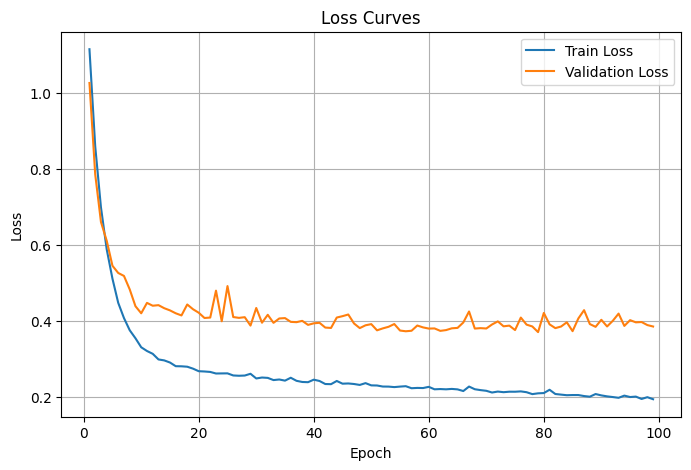

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"],      label="Train Loss")
plt.plot(history_df["epoch"], history_df["validation_loss"], label="Validation Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.grid(True)
plt.savefig(FIGURE_DIR / "loss_curve.png", dpi=300)
plt.show()

### 11.3 Dice Curve

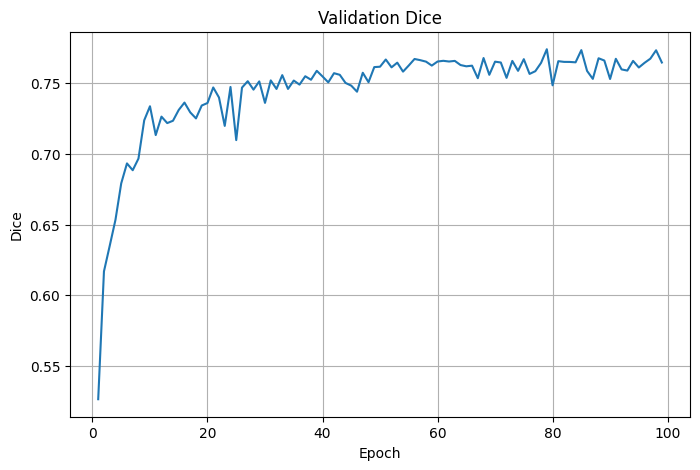

In [39]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["validation_dice"])
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title("Validation Dice")
plt.grid(True)
plt.savefig(FIGURE_DIR / "dice_curve.png", dpi=300)
plt.show()

### 11.4 Summary

In [40]:
print("=" * 60)
print("Training Completed")
print("=" * 60)
print()
print(f"Best Dice  : {best_dice:.4f}")
print(f"Best Epoch : {best_epoch}")
print()
print("Artifacts saved:")
print(f"  {CHECKPOINT_DIR / 'best_model.pth'}")
print(f"  {CHECKPOINT_DIR / 'last_model.pth'}")
print(f"  {LOG_DIR / 'training_history.csv'}")
print(f"  {FIGURE_DIR / 'loss_curve.png'}")
print(f"  {FIGURE_DIR / 'dice_curve.png'}")

Training Completed

Best Dice  : 0.7741
Best Epoch : 79

Artifacts saved:
  /kaggle/working/models/segmentation/best_model.pth
  /kaggle/working/models/segmentation/last_model.pth
  /kaggle/working/logs/training_history.csv
  /kaggle/working/reports/figures/loss_curve.png
  /kaggle/working/reports/figures/dice_curve.png
